<a href="https://colab.research.google.com/github/liangwan2023/MachineLearning/blob/main/Assignment_4_WanqinLiang_Final_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4 — Support Vector Machines

This notebook is a fully corrected Part 2 workflow for the breast cancer image classification task.

## What is fixed compared with the original version
- **No data leakage**: train/test split happens **before** feature selection and normalization.
- **Top 4 features** are selected using **ANOVA F-test** on the **training set only**.
- **Normalization** uses `StandardScaler` fit on the **training set only**.
- **Kernel comparison and hyperparameter tuning** are included using `GridSearchCV`.
- **Evaluation** reports confusion matrix, accuracy, precision, recall, and F1-score, with emphasis on **malignant recall/F1**.

## Expected dataset structure
Either:
- `Data.zip` in the same folder as this notebook, **or**
- an extracted `Data/` folder containing:
  - `Data/Benign/*.png`
  - `Data/Malignant/*.png`

> The assignment PDF asks for 61 images, a CSV of extracted features, top-4 feature selection, normalization, SVM model building, and evaluation with justified metrics and SVM settings.


In [ ]:

# =========================
# 1) Imports and settings
# =========================
import os
import glob
import zipfile
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

# -------------------------
# Configuration
# -------------------------
ZIP_PATH = "Data.zip"
DATASET_PATH = "Data"
IMAGE_SIZE = (256, 256)
RANDOM_STATE = 42
TEST_SIZE = 0.20
TOP_K = 4

FULL_FEATURES_CSV = "breast_cancer_features.csv"
TRAIN_SELECTED_CSV = "train_top4_normalized.csv"
TEST_SELECTED_CSV = "test_top4_normalized.csv"

print("Configuration loaded.")


Configuration loaded.


In [ ]:

# ===========================================
# 2) Extract dataset if needed + basic checks
# ===========================================



import os
import glob
import zipfile

# Extract dataset only if the folder does not already exist
if not os.path.exists(DATASET_PATH):
    if not os.path.exists(ZIP_PATH):
        raise FileNotFoundError(f"'{ZIP_PATH}' not found in the working directory.")

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(".")

# Define class folders
benign_dir = os.path.join(DATASET_PATH, "Benign")
malignant_dir = os.path.join(DATASET_PATH, "Malignant")

# Check expected folder structure
if not os.path.isdir(benign_dir) or not os.path.isdir(malignant_dir):
    raise FileNotFoundError(
        "Expected folder structure:\n"
        "Data/Benign/*.png\n"
        "Data/Malignant/*.png"
    )

# Load image file paths
benign_files = sorted(glob.glob(os.path.join(benign_dir, "*.png")))
malignant_files = sorted(glob.glob(os.path.join(malignant_dir, "*.png")))

# Basic dataset statistics
print("Benign images   :", len(benign_files))
print("Malignant images:", len(malignant_files))
print("Total images    :", len(benign_files) + len(malignant_files))

Benign images   : 30
Malignant images: 31
Total images    : 61


## Feature extraction rationale

The assignment asks for relevant **texture, shape, and edge** features.  
This notebook extracts:

- **Texture**: grayscale mean/std and HOG mean/std  
- **Edge**: Canny edge density and Sobel edge magnitude mean  
- **Shape**: largest contour area, perimeter, circularity, aspect ratio  
- **Color**: mean red, green, and blue values

These features are simple, interpretable, and computationally efficient for a small dataset.


In [ ]:

# =========================
# 3) Feature extraction
# =========================
def extract_features(image_path, image_size=(256, 256)):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, image_size)
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Texture features
    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True,
    )
    gray_mean = float(np.mean(gray))
    gray_std = float(np.std(gray))
    hog_mean = float(np.mean(hog_features))
    hog_std = float(np.std(hog_features))

    # Edge features
    edges = cv2.Canny(gray, 100, 200)
    edge_density = float(np.sum(edges > 0) / edges.size)

    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    edge_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    edge_mean = float(np.mean(edge_magnitude))

    # Shape features
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    area = 0.0
    perimeter = 0.0
    circularity = 0.0
    aspect_ratio = 0.0

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        area = float(cv2.contourArea(largest_contour))
        perimeter = float(cv2.arcLength(largest_contour, True))
        if perimeter > 0:
            circularity = float((4 * np.pi * area) / (perimeter ** 2))

        x, y, w, h = cv2.boundingRect(largest_contour)
        if h > 0:
            aspect_ratio = float(w / h)

    # Color features
    r_mean = float(np.mean(image[:, :, 0]))
    g_mean = float(np.mean(image[:, :, 1]))
    b_mean = float(np.mean(image[:, :, 2]))

    return {
        "gray_mean": gray_mean,
        "gray_std": gray_std,
        "hog_mean": hog_mean,
        "hog_std": hog_std,
        "edge_density": edge_density,
        "edge_mean": edge_mean,
        "area": area,
        "perimeter": perimeter,
        "circularity": circularity,
        "aspect_ratio": aspect_ratio,
        "r_mean": r_mean,
        "g_mean": g_mean,
        "b_mean": b_mean,
    }


def build_feature_dataset(dataset_path):
    rows = []
    class_folders = {
        "Benign": "B",
        "Malignant": "M",
    }

    for folder_name, class_label in class_folders.items():
        folder_path = os.path.join(dataset_path, folder_name)
        image_paths = sorted(glob.glob(os.path.join(folder_path, "*.png")))

        for image_path in image_paths:
            features = extract_features(image_path, image_size=IMAGE_SIZE)
            features["image_name"] = os.path.basename(image_path)
            features["class"] = class_label
            rows.append(features)

    df = pd.DataFrame(rows)

    # Put metadata columns first/last for readability
    ordered_cols = (
        ["image_name"]
        + [c for c in df.columns if c not in ["image_name", "class"]]
        + ["class"]
    )
    return df[ordered_cols]


df_features = build_feature_dataset(DATASET_PATH)
df_features.to_csv(FULL_FEATURES_CSV, index=False)

print("Feature extraction completed.")
print("Saved full feature dataset to:", FULL_FEATURES_CSV)
print("Dataset shape:", df_features.shape)
print("\nClass distribution:")
print(df_features["class"].value_counts())
df_features.head()


Feature extraction completed.
Saved full feature dataset to: breast_cancer_features.csv
Dataset shape: (61, 15)

Class distribution:
class
M    31
B    30
Name: count, dtype: int64


,image_name,gray_mean,gray_std,hog_mean,hog_std,edge_density,edge_mean,area,perimeter,circularity,aspect_ratio,r_mean,g_mean,b_mean,class
0,SOB_B_A-14-22549AB-100-001.png,183.917816,25.413612,0.142718,0.086077,0.136658,66.404861,29470.0,4367.129397,0.019418,1.000000,187.443649,180.776199,190.842712,B
1,SOB_B_A-14-22549AB-100-002.png,180.505035,24.046194,0.141881,0.087451,0.129990,67.319936,7526.0,575.671134,0.285381,0.879032,185.760025,176.111893,189.293518,B
2,SOB_B_A-14-22549AB-100-003.png,177.599457,26.085522,0.148332,0.075996,0.180969,82.966010,21384.0,4836.991436,0.011485,0.937500,185.731812,171.384399,188.245819,B
3,SOB_B_A-14-22549AB-100-004.png,184.413971,32.563332,0.137435,0.094284,0.176788,79.914293,8352.5,2389.873355,0.018377,0.308594,183.821976,183.995667,188.189453,B
4,SOB_B_A-14-22549AB-100-005.png,176.913696,28.590387,0.147752,0.077117,0.193710,83.741504,15475.0,3769.163887,0.013688,0.832031,180.499634,173.380676,185.720474,B


## Why split before feature selection and scaling?

To avoid **data leakage**.

If feature selection or normalization is fitted on the full dataset before the split, the test set influences training.  
That makes evaluation overly optimistic. The correct sequence is:

1. Build the full feature dataset  
2. Split into train/test  
3. Fit feature selector on **training only**  
4. Fit scaler on **training only**  
5. Apply those fitted transformations to the test set


In [ ]:

# ==========================================
# 4) Split the dataset BEFORE model fitting
# ==========================================
df = pd.read_csv(FULL_FEATURES_CSV)

X = df.drop(columns=["image_name", "class"])
y = df["class"].map({"B": 0, "M": 1})  # B=0, M=1

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts().sort_index().rename(index={0: "B", 1: "M"}))
print("\nTest class distribution:")
print(y_test.value_counts().sort_index().rename(index={0: "B", 1: "M"}))


Train shape: (48, 13)
Test shape : (13, 13)

Train class distribution:
class
B    24
M    24
Name: count, dtype: int64

Test class distribution:
class
B    6
M    7
Name: count, dtype: int64


## Feature selection method

This notebook uses **ANOVA F-test** with `SelectKBest(k=4)`.

### Why this is reasonable here
- The dataset is small, so a simple filter method is appropriate.
- ANOVA F-test ranks features by how strongly each feature differs across the two classes.
- It is fast, interpretable, and directly supports the assignment requirement to identify the **top 4 features**.

To avoid leakage, the selector is fit **only on the training set**.


In [ ]:

# =====================================
# 5) Feature selection on training only
# =====================================
selector = SelectKBest(score_func=f_classif, k=TOP_K)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_feature_names = X_train.columns[selector.get_support()].tolist()

feature_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "ANOVA_F_Score": selector.scores_
}).sort_values("ANOVA_F_Score", ascending=False)

print("Top 4 selected features:")
for i, feat in enumerate(selected_feature_names, start=1):
    print(f"{i}. {feat}")

print("\nAll feature scores:")
display(feature_scores)

X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_feature_names, index=X_train.index)
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_feature_names, index=X_test.index)


Top 4 selected features:
1. gray_mean
2. r_mean
3. g_mean
4. b_mean

All feature scores:


,Feature,ANOVA_F_Score
12,b_mean,1251.111638
10,r_mean,665.573409
0,gray_mean,449.624569
11,g_mean,144.182526
4,edge_density,44.554755
5,edge_mean,39.636390
3,hog_std,25.470245
2,hog_mean,24.251619
6,area,17.181061
8,circularity,3.067262


## Normalization method

This notebook uses **StandardScaler**.

### Why StandardScaler?
SVMs are distance/margin-based models and are sensitive to feature scale.  
Standardization transforms features to zero mean and unit variance, preventing large-scale variables such as area or perimeter from dominating smaller-scale variables.

Again, the scaler is fit **only on the training set**.


In [ ]:

# =================================
# 6) Normalize training/test data
# =================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected_df)
X_test_scaled = scaler.transform(X_test_selected_df)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=selected_feature_names, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=selected_feature_names, index=X_test.index)

# Save model-ready train/test CSV files
train_export = X_train_scaled_df.copy()
train_export["class"] = y_train.map({0: "B", 1: "M"})

test_export = X_test_scaled_df.copy()
test_export["class"] = y_test.map({0: "B", 1: "M"})

train_export.to_csv(TRAIN_SELECTED_CSV, index=False)
test_export.to_csv(TEST_SELECTED_CSV, index=False)

print("Saved normalized training data to:", TRAIN_SELECTED_CSV)
print("Saved normalized test data to    :", TEST_SELECTED_CSV)
print("\nTraining data preview:")
display(train_export.head())


Saved normalized training data to: train_top4_normalized.csv
Saved normalized test data to    : test_top4_normalized.csv

Training data preview:


,gray_mean,r_mean,g_mean,b_mean,class
31,1.265614,1.296452,1.190029,1.165909,M
4,-1.316887,-1.313431,-1.261180,-1.235233,B
8,-1.145695,-0.801787,-1.436413,-0.917189,B
42,1.180699,1.015111,1.322338,0.934954,M
33,0.586558,0.608110,0.492308,0.713307,M


## SVM model building and kernel comparison

The assignment asks not only to build an SVM, but also to justify kernel choice and settings.

This notebook compares several kernels and hyperparameters with **GridSearchCV**:

- `linear`
- `rbf`
- `poly`

### Why score by F1?
For cancer detection, missing a malignant case is serious.  
Accuracy alone can be misleading, especially on small datasets.  
F1 balances **precision** and **recall**, while recall for the malignant class is also reported explicitly.


In [ ]:

# ============================================
# 7) Hyperparameter tuning and kernel comparison
# ============================================
param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 10, 100],
    },
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", 0.01, 0.1, 1],
    },
    {
        "kernel": ["poly"],
        "C": [0.1, 1, 10],
        "degree": [2, 3],
        "gamma": ["scale", 0.01, 0.1],
    },
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_

cv_results = pd.DataFrame(grid_search.cv_results_).sort_values(
    by="rank_test_score"
)[[
    "params", "mean_test_score", "std_test_score", "rank_test_score"
]]

print("Best parameters:")
print(grid_search.best_params_)
print("\nBest cross-validated F1:", round(grid_search.best_score_, 4))
print("\nTop grid-search results:")
display(cv_results.head(10))


Best parameters:
{'C': 0.1, 'kernel': 'linear'}

Best cross-validated F1: 1.0

Top grid-search results:


,params,mean_test_score,std_test_score,rank_test_score
0,"{'C': 0.1, 'kernel': 'linear'}",1.0,0.0,1
1,"{'C': 1, 'kernel': 'linear'}",1.0,0.0,1
2,"{'C': 10, 'kernel': 'linear'}",1.0,0.0,1
3,"{'C': 100, 'kernel': 'linear'}",1.0,0.0,1
4,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}",1.0,0.0,1
6,"{'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}",1.0,0.0,1
7,"{'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}",1.0,0.0,1
8,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",1.0,0.0,1
12,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",1.0,0.0,1
9,"{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}",1.0,0.0,1


In [ ]:

# =========================
# 8) Final test evaluation
# =========================
y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision_m = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_m = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1_m = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

print("Selected features used by the model:", selected_feature_names)
print("Best model:", best_model)
print("\nConfusion Matrix:")
print(cm)

print("\nAccuracy               :", round(accuracy, 4))
print("Precision (Malignant)  :", round(precision_m, 4))
print("Recall / Sensitivity   :", round(recall_m, 4))
print("F1-score (Malignant)   :", round(f1_m, 4))

print("\nDetailed classification report:")
print(classification_report(
    y_test, y_pred,
    target_names=["Benign", "Malignant"],
    zero_division=0
))


Selected features used by the model: ['gray_mean', 'r_mean', 'g_mean', 'b_mean']
Best model: SVC(C=0.1, kernel='linear')

Confusion Matrix:
[[6 0]
 [0 7]]

Accuracy               : 1.0
Precision (Malignant)  : 1.0
Recall / Sensitivity   : 1.0
F1-score (Malignant)   : 1.0

Detailed classification report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00         6
   Malignant       1.00      1.00      1.00         7

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



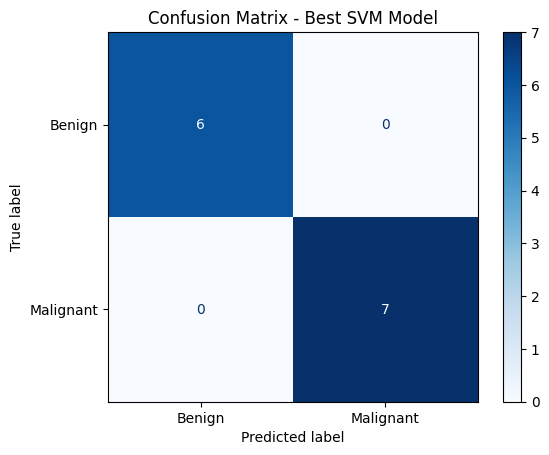

In [ ]:

# =========================================
# 9) Plot confusion matrix for the report
# =========================================
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Best SVM Model")
plt.show()


## Short discussion text you can adapt for your report

### Feature extraction
Texture, edge, shape, and color descriptors were extracted from each image because histopathological cancer images may differ in tissue structure, boundary irregularity, and overall visual appearance. HOG and grayscale statistics capture texture, Canny/Sobel capture edge strength, contour-based measurements capture morphology, and RGB means capture global color information.

### Feature selection
ANOVA F-test was used to rank features by class-discriminative power, and the top 4 features were selected. This method is appropriate for a small dataset because it is simple, interpretable, and computationally efficient. To avoid data leakage, the selector was fit only on the training set.

### Normalization
StandardScaler was used because SVMs are sensitive to feature scale. Standardization prevents large-valued measurements such as area or perimeter from dominating smaller-valued features.

### Model building and kernel choice
A grid search compared linear, RBF, and polynomial kernels across multiple hyperparameter settings. This was done to justify kernel selection rather than assuming that one kernel would always be best. If the best model is RBF, that supports the idea that the class boundary is nonlinear and benefits from the kernel trick.

### Evaluation
The confusion matrix, accuracy, precision, recall, and F1-score were reported. For breast cancer detection, recall for the malignant class is especially important because false negatives are more harmful than false positives. F1-score is also useful because it balances precision and recall on the malignant class.
